# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_csv('data.csv')
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

# Basic info
print("\nDataset Info:")
df.info()

# Check target variable
print("\nTarget Distribution:")
print(df['y'].value_counts())

Dataset Shape: (41188, 21)

First 5 rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-n

## Customer Demographics Analysis

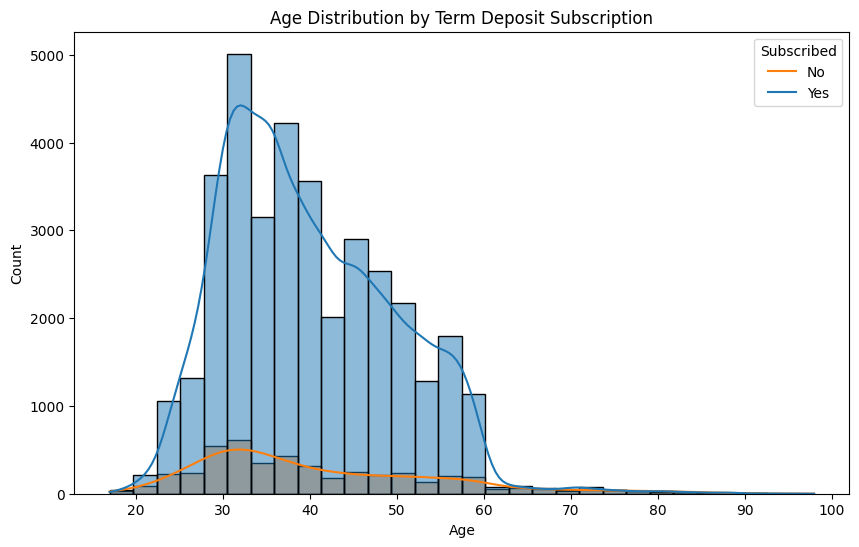

Age Statistics by Subscription:
       count       mean        std   min   25%   50%   75%   max
y                                                               
no   36548.0  39.911185   9.898132  17.0  32.0  38.0  47.0  95.0
yes   4640.0  40.913147  13.837476  17.0  31.0  37.0  50.0  98.0


In [10]:
# Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='y', bins=30, kde=True)
plt.title('Age Distribution by Term Deposit Subscription')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Subscribed', labels=['No', 'Yes'])
plt.show()

# Age statistics
print("Age Statistics by Subscription:")
print(df.groupby('y')['age'].describe())

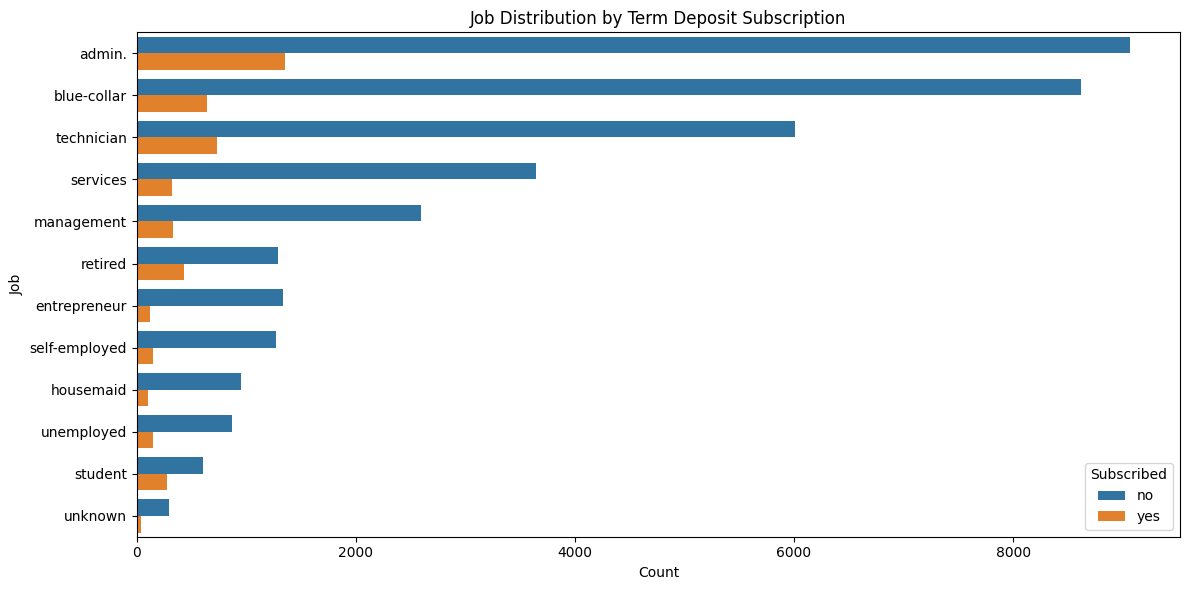

Subscription Rate by Job (%):
job
admin.           12.972558
blue-collar       6.894316
entrepreneur      8.516484
housemaid        10.000000
management       11.217510
retired          25.232558
self-employed    10.485574
services          8.138070
student          31.428571
technician       10.826042
unemployed       14.201183
unknown          11.212121
Name: yes, dtype: float64


In [3]:
# Job distribution
plt.figure(figsize=(12, 6))
job_counts = df['job'].value_counts()
sns.countplot(data=df, y='job', hue='y', order=job_counts.index)
plt.title('Job Distribution by Term Deposit Subscription')
plt.xlabel('Count')
plt.ylabel('Job')
plt.legend(title='Subscribed')
plt.tight_layout()
plt.show()

# Subscription rate by job
job_sub = df.groupby('job')['y'].value_counts(normalize=True).unstack()
print("Subscription Rate by Job (%):")
print(job_sub['yes'] * 100)

## Balance & Deposit Trends

Note: 'balance' column not found. Using duration instead.


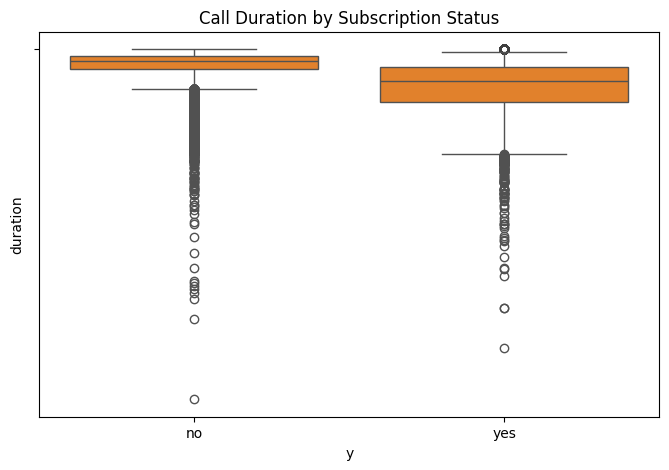


Average Duration by Subscription:
y
no     220.844807
yes    553.191164
Name: duration, dtype: float64


In [4]:
# Average balance by deposit subscription
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='y', y='balance' if 'balance' in df.columns else None)
plt.title('Balance Distribution by Subscription Status')

# If there's no 'balance' column, use duration or another relevant one
if 'balance' not in df.columns:
    print("Note: 'balance' column not found. Using duration instead.")
    sns.boxplot(data=df, x='y', y='duration')
    plt.title('Call Duration by Subscription Status')

plt.show()

print("\nAverage Duration by Subscription:")
print(df.groupby('y')['duration'].mean())


## Campaign Effectiveness

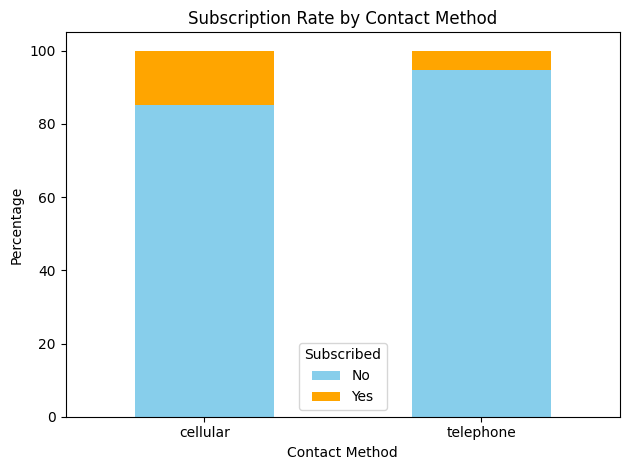

Subscription Rate by Contact Method:
y                 no        yes
contact                        
cellular   85.262393  14.737607
telephone  94.768679   5.231321


In [5]:
# Contact method analysis 
contact_sub = pd.crosstab(df['contact'], df['y'], normalize='index') * 100
contact_sub.plot(kind='bar', stacked=True, color=['skyblue', 'orange'])
plt.title('Subscription Rate by Contact Method')
plt.ylabel('Percentage')
plt.xlabel('Contact Method')
plt.legend(title='Subscribed', labels=['No', 'Yes'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Subscription Rate by Contact Method:")
print(contact_sub)

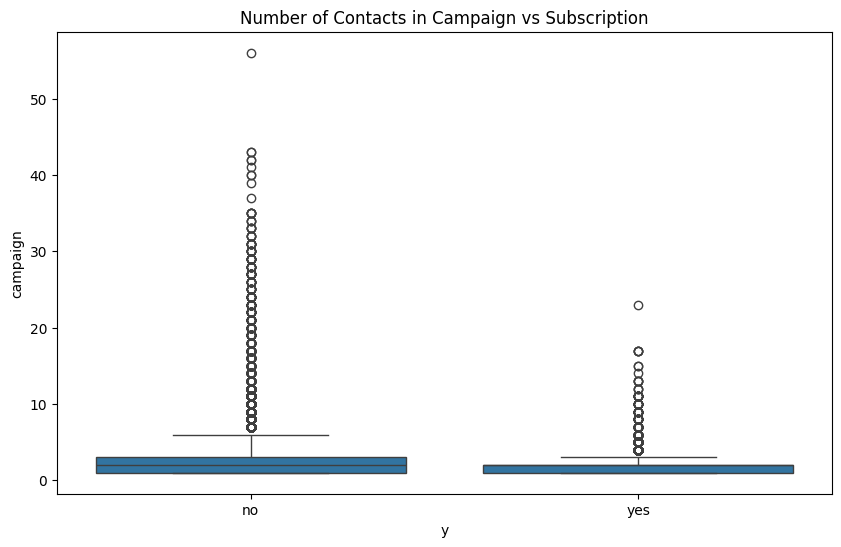


Average Campaign Contacts by Subscription:
y
no     2.633085
yes    2.051724
Name: campaign, dtype: float64


In [6]:
# Number of contacts vs deposit subscription
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='y', y='campaign')
plt.title('Number of Contacts in Campaign vs Subscription')
plt.show()

print("\nAverage Campaign Contacts by Subscription:")
print(df.groupby('y')['campaign'].mean())

## Correlation Heatmap

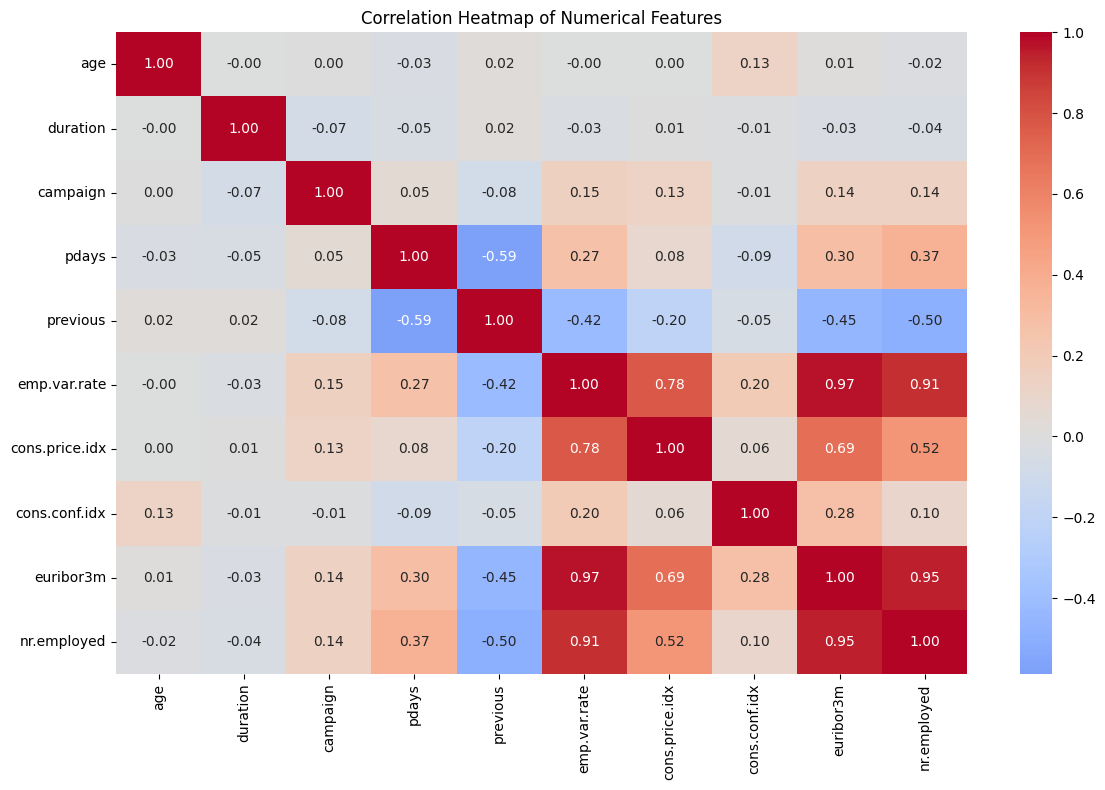

In [7]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))

# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

## Predictive Modeling (Logistic Regression)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Make a copy
df_model = df.copy()

# Encode categorical variables
categorical_cols = df_model.select_dtypes(include=['object']).columns
le_dict = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le

# Features and target
X = df_model.drop('y', axis=1)
y = df_model['y']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.910091446143886

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     10968
           1       0.66      0.41      0.50      1389

    accuracy                           0.91     12357
   macro avg       0.80      0.69      0.73     12357
weighted avg       0.90      0.91      0.90     12357



C:\Users\Owner\AppData\Local\Temp\ipykernel_26876\2031333499.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_model.select_dtypes(include=['object']).columns


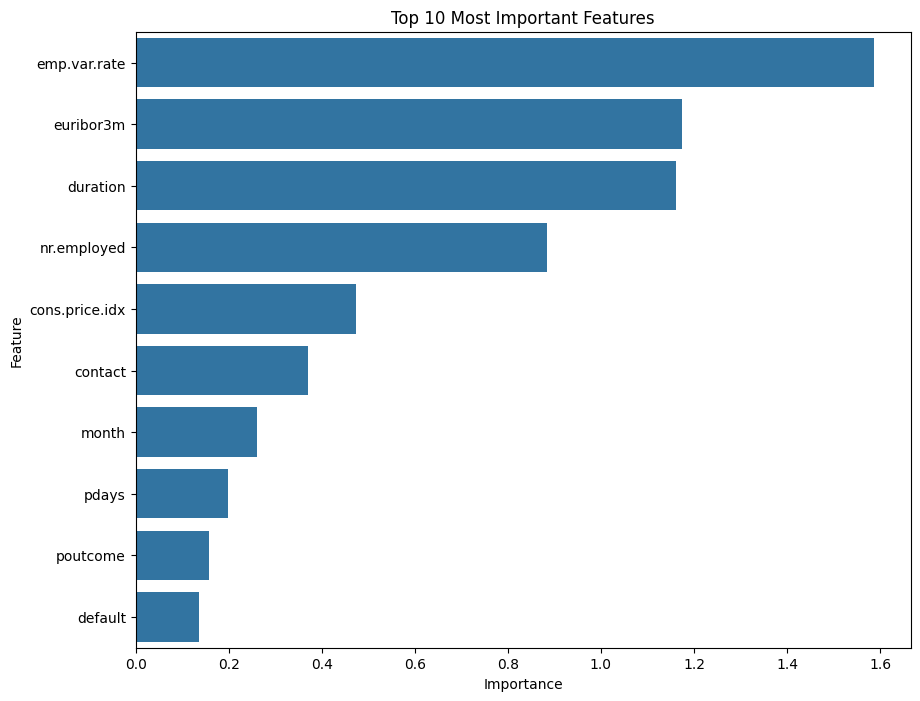


Top 10 Important Features:
           Feature  Importance
15    emp.var.rate    1.586485
18       euribor3m    1.175391
10        duration    1.160910
19     nr.employed    0.885234
16  cons.price.idx    0.473249
7          contact    0.369613
8            month    0.260932
12           pdays    0.199327
14        poutcome    0.157537
4          default    0.135209


In [9]:
# Feature importance (using coefficients)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(model.coef_[0])
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature')
plt.title('Top 10 Most Important Features')
plt.show()

print("\nTop 10 Important Features:")
print(feature_importance.head(10))

## Key Takeaways

- Age: Customers aged 30-40 and above 60 show higher subscription rates.
- Job: Students and retired people have the highest subscription rates (31% and 25% respectively).
- Duration: Longer call duration strongly correlates with higher subscription success.
- Contact Method: Cellular contact performs much better than telephone.
- Campaign: Fewer contacts in a campaign tend to yield better results.
- Economic Factors: Employment variation rate and Euribor rate are the strongest predictors.
- Model Performance: Logistic Regression achieved **91% accuracy**, with duration, economic indicators, and contact method being key drivers.